

## Objective
The objective of this project is to build a machine learning model that can predict whether a loan application will be approved or rejected based on the applicant's financial and personal details.

## Problem Type
This is a supervised machine learning problem because the dataset contains input features along with the known output. More specifically, it is a classification problem because the target variable has two categories: Approved and Rejected.

## Target Variable
The target variable in this dataset is `loan_status`.

## Input Features
The dataset includes applicant-related and financial features such as:
- number of dependents
- education
- self employment status
- annual income
- loan amount
- loan term
- CIBIL score
- residential asset value
- commercial asset value
- luxury asset value
- bank asset value

## Project Goal
The main goal is to analyze the dataset, preprocess the data, train multiple machine learning models, compare their performance, and select the best model for loan approval prediction.

## Real-World Use
This type of model can help financial institutions make faster and more consistent loan approval decisions by identifying patterns in past loan application data.

In [36]:
import pandas as pd

df = pd.read_csv("../Dataset/LoanApprovalSynthetic/loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


From the initial preview, we can see that the dataset contains applicant-related financial information and the target column `loan_status`, which indicates whether the loan was approved or rejected.

In [37]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4269
Number of columns: 13


In [38]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


# Step 3: Data Preprocessing

## Objective
The objective of this step is to clean and prepare the dataset for exploratory data analysis and machine learning model building.

## Why Preprocessing is Needed
Raw data is not always directly suitable for analysis. It may contain unwanted spaces, unnecessary columns, categorical text values, duplicates, or missing values. Preprocessing improves the quality of the dataset and ensures that it is ready for model training.

In [40]:
df.columns = df.columns.str.strip()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')

The column names contained extra spaces, which can create problems while accessing columns. Therefore, the spaces were removed using the `str.strip()` function.


In [41]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

The dataset does not contain missing values, so no missing value treatment is required.

In [42]:
df.duplicated().sum()
df = df.drop_duplicates()


In [43]:
df.drop("loan_id", axis=1, inplace=True)
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [44]:
print(df["education"].unique())
print(df["self_employed"].unique())
print(df["loan_status"].unique())

<StringArray>
[' Graduate', ' Not Graduate']
Length: 2, dtype: str
<StringArray>
[' No', ' Yes']
Length: 2, dtype: str
<StringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str


In [45]:
df["education"] = df["education"].str.strip()
df["self_employed"] = df["self_employed"].str.strip()
df["loan_status"] = df["loan_status"].str.strip()
df["education"] = df["education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

df["self_employed"] = df["self_employed"].map({
    "Yes": 1,
    "No": 0
})


The categorical input columns `education` and `self_employed` were converted into numerical form using label mapping. This makes them suitable for machine learning algorithms.


In [46]:
df["loan_status"] = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})


The target variable `loan_status` was encoded into numerical form, where `Approved` was mapped to 1 and `Rejected` was mapped to 0. This is necessary because classification models require numerical target values.


In [47]:
df.head()



,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [48]:
df.describe()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000
mean,2.498712,0.502225,0.503631,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160
std,1.695910,0.500054,0.500045,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904
min,0.000000,0.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000
25%,1.000000,0.000000,0.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000
50%,3.000000,1.000000,1.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000
75%,4.000000,1.000000,1.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000
max,5.000000,1.000000,1.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07,1.000000


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   int64
 2   self_employed             4269 non-null   int64
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   int64
dtypes: int64(12)
memory usage: 400.3 KB


The preprocessing step successfully cleaned the dataset and transformed it into a format suitable for analysis and machine learning. Unnecessary columns were removed, categorical values were encoded, and the dataset is now ready for exploratory data analysis in the next step.

# Step 4: Exploratory Data Analysis (EDA)

## Objective
The objective of this step is to explore the dataset visually and statistically in order to understand the distribution of features, relationships between variables, and patterns affecting loan approval.

## Why EDA is Important
EDA helps in understanding the structure of the dataset before model training. It allows us to identify trends, class distribution, possible outliers, and the most influential variables related to loan approval status.


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [51]:
df.describe()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000
mean,2.498712,0.502225,0.503631,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160
std,1.695910,0.500054,0.500045,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904
min,0.000000,0.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000
25%,1.000000,0.000000,0.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000
50%,3.000000,1.000000,1.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000
75%,4.000000,1.000000,1.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000
max,5.000000,1.000000,1.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07,1.000000


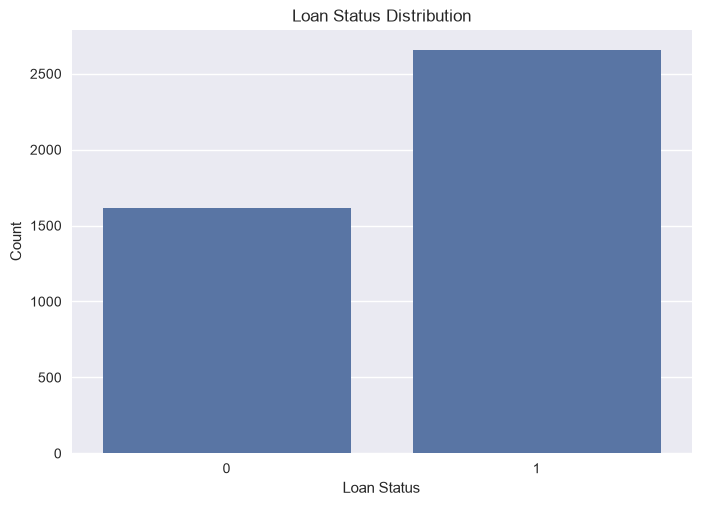

In [52]:
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

The target variable distribution shows how many loan applications were approved and how many were rejected. This is useful for checking whether the dataset is balanced or imbalanced.

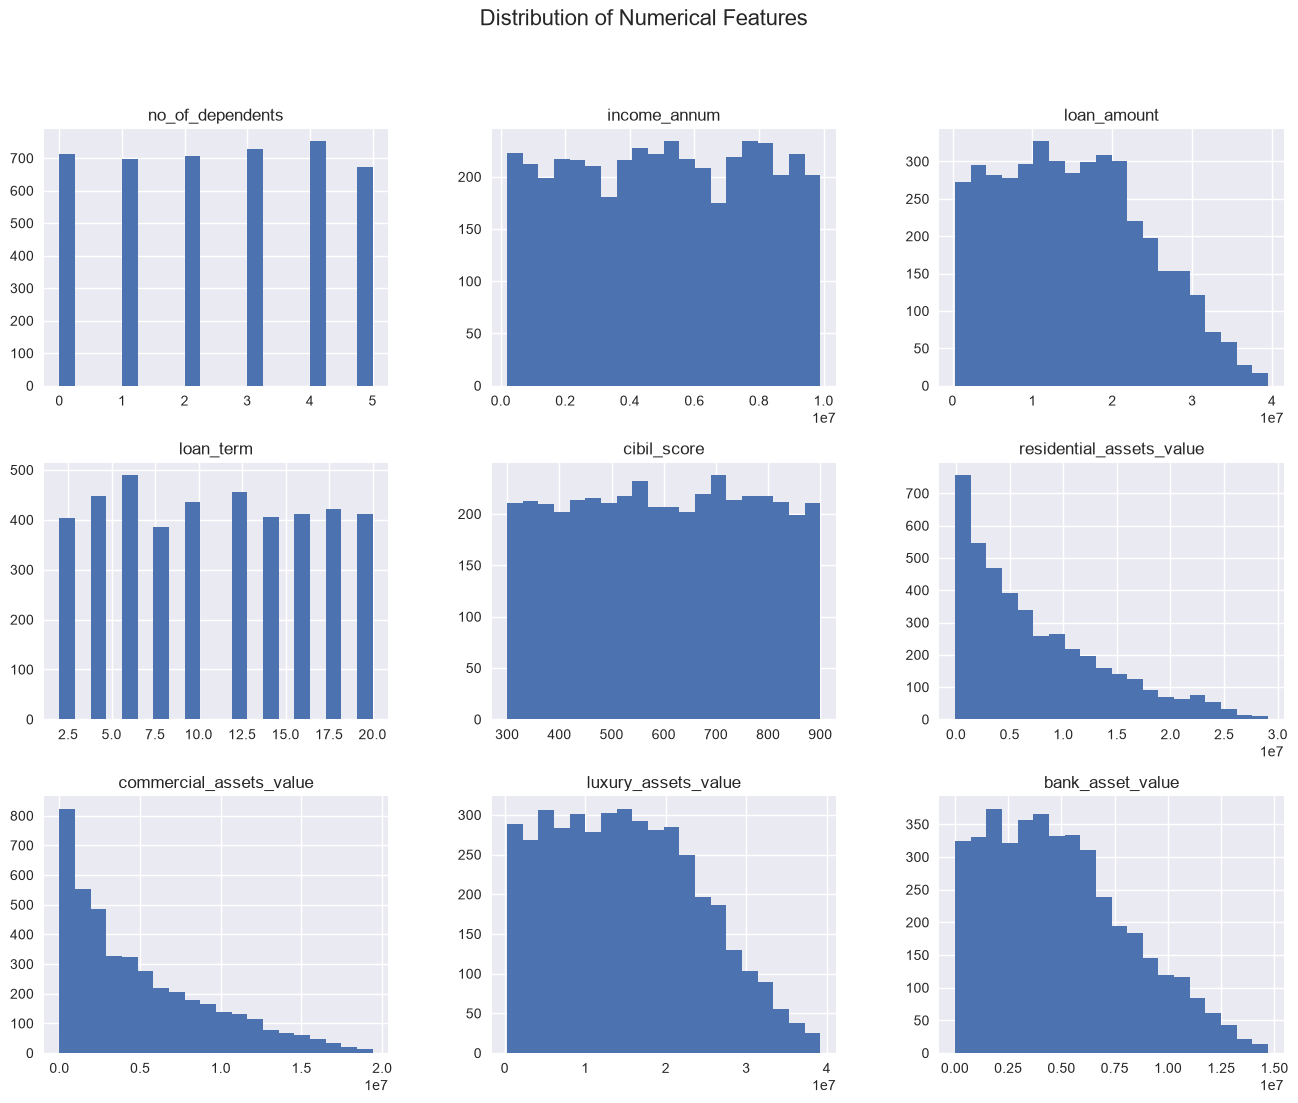

In [53]:
num_cols = [
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]

df[num_cols].hist(figsize=(16, 12), bins=20)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

Histograms help visualize how numerical features are distributed. They show whether values are spread evenly, concentrated in certain ranges, or affected by skewness and outliers.

C:\Users\varun\AppData\Local\Temp\ipykernel_2984\1756465020.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Not Graduate", "Graduate"])
C:\Users\varun\AppData\Local\Temp\ipykernel_2984\1756465020.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["No", "Yes"])


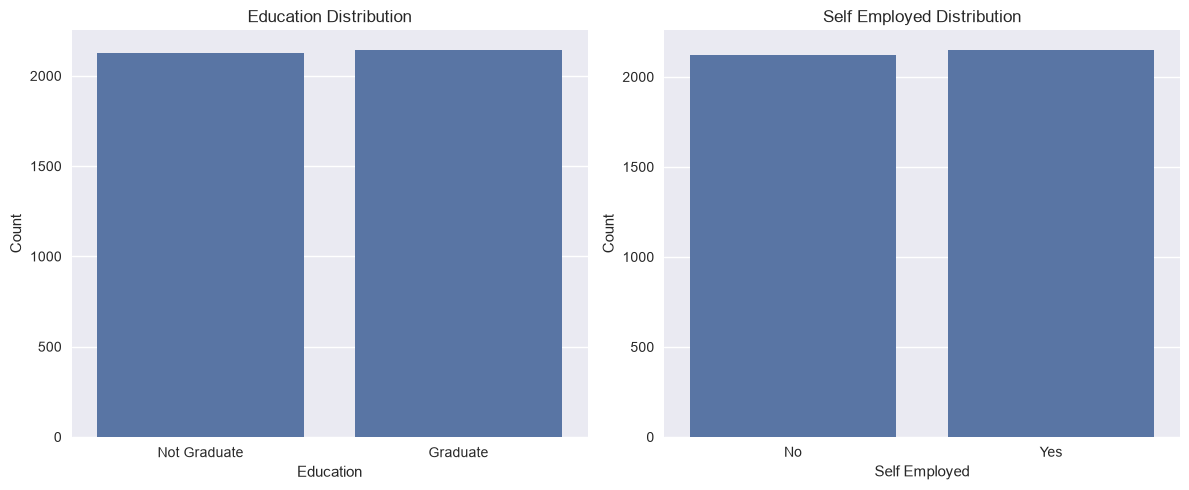

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="education", data=df, ax=axes[0])
axes[0].set_title("Education Distribution")
axes[0].set_xlabel("Education")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Not Graduate", "Graduate"])

sns.countplot(x="self_employed", data=df, ax=axes[1])
axes[1].set_title("Self Employed Distribution")
axes[1].set_xlabel("Self Employed")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["No", "Yes"])

plt.tight_layout()
plt.show()

Count plots are used to analyze categorical features. They help us understand how many applicants belong to each category, such as education level and self-employment status.

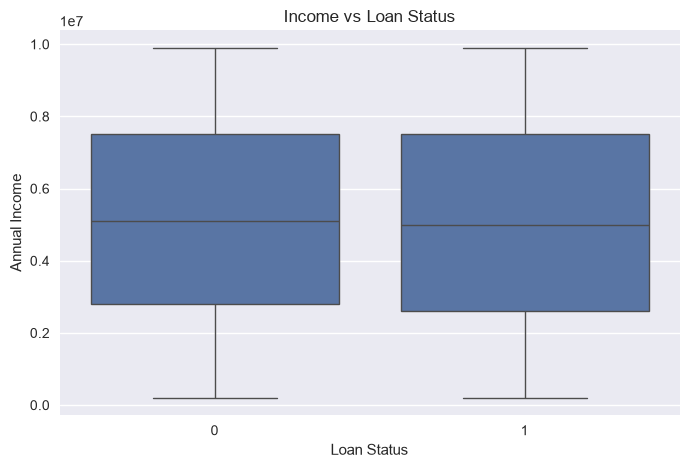

In [55]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="loan_status", y="income_annum", data=df)
plt.title("Income vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")
plt.show()

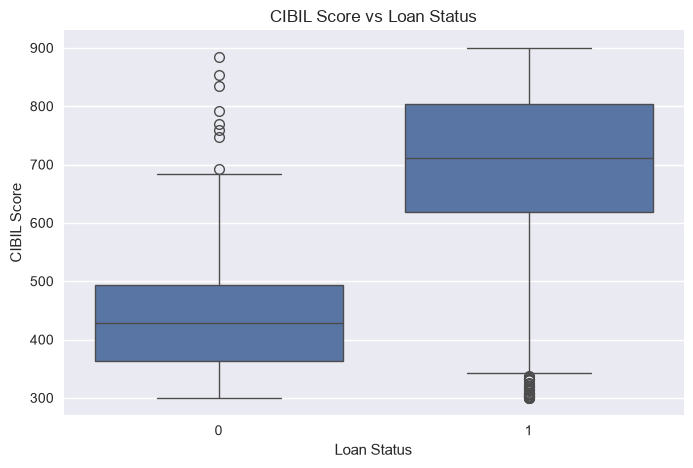

In [56]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="loan_status", y="cibil_score", data=df)
plt.title("CIBIL Score vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("CIBIL Score")
plt.show()

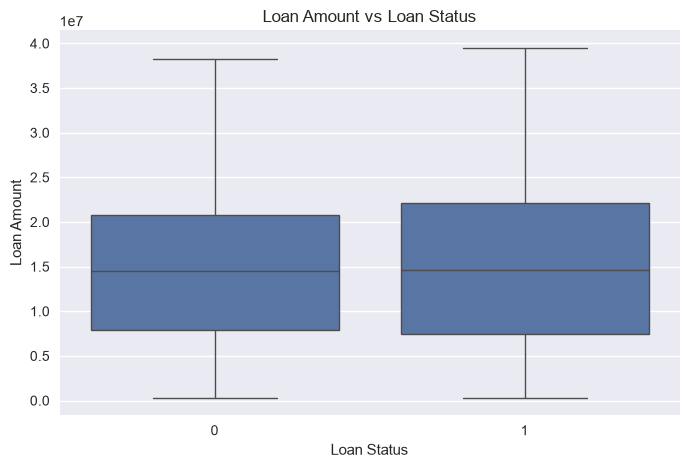

In [57]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="loan_status", y="loan_amount", data=df)
plt.title("Loan Amount vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()

Box plots help compare numerical features across the two loan status classes. They are useful for identifying whether approved and rejected loans differ significantly in terms of income, credit score, or loan amount.

C:\Users\varun\AppData\Local\Temp\ipykernel_2984\4176606111.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Not Graduate", "Graduate"])
C:\Users\varun\AppData\Local\Temp\ipykernel_2984\4176606111.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["No", "Yes"])


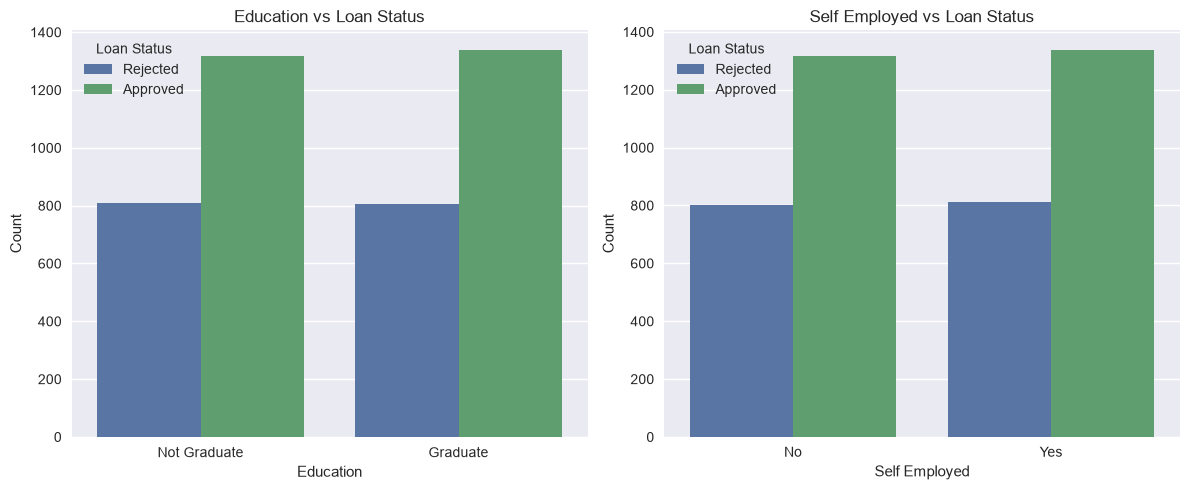

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="education", hue="loan_status", data=df, ax=axes[0])
axes[0].set_title("Education vs Loan Status")
axes[0].set_xlabel("Education")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Not Graduate", "Graduate"])
axes[0].legend(title="Loan Status", labels=["Rejected", "Approved"])

sns.countplot(x="self_employed", hue="loan_status", data=df, ax=axes[1])
axes[1].set_title("Self Employed vs Loan Status")
axes[1].set_xlabel("Self Employed")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["No", "Yes"])
axes[1].legend(title="Loan Status", labels=["Rejected", "Approved"])

plt.tight_layout()
plt.show()

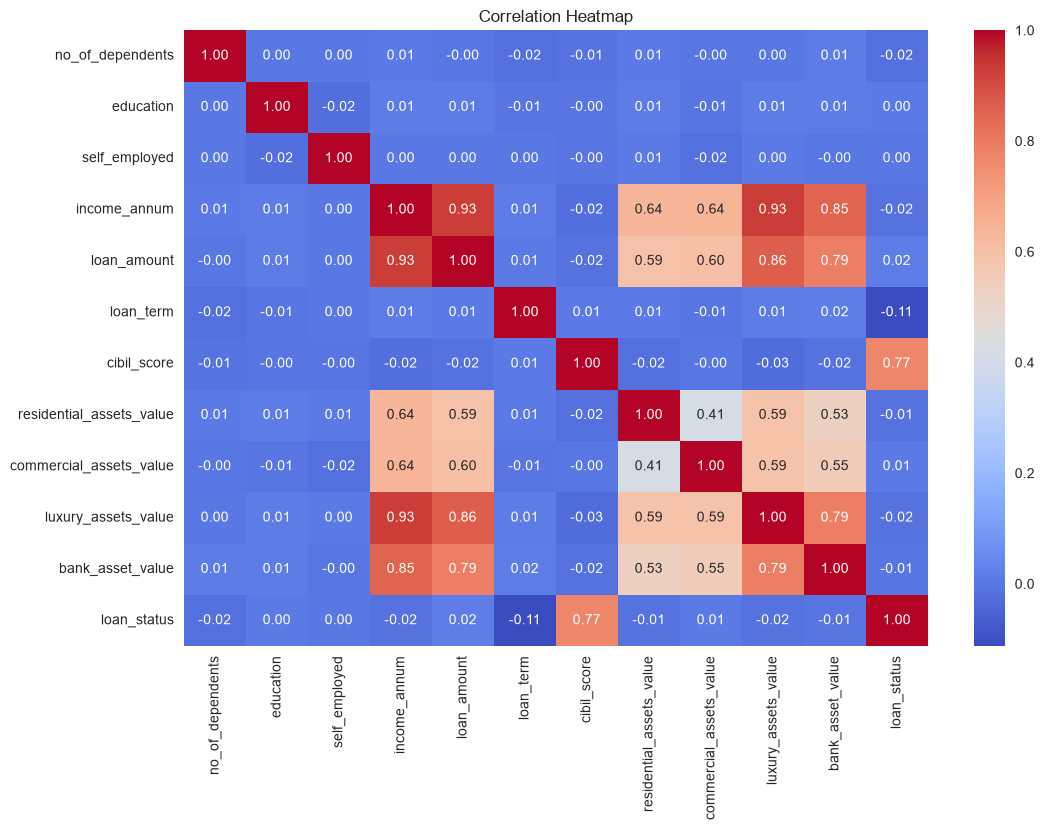

In [59]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows the strength and direction of relationships between numerical variables. It helps identify which features are positively or negatively related to loan approval and whether some input features are strongly related to each other.

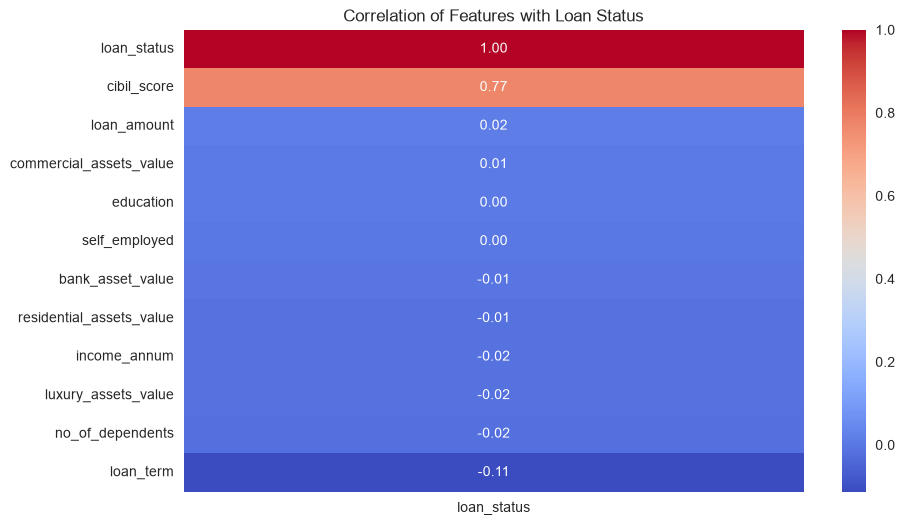

In [60]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr()[["loan_status"]].sort_values(by="loan_status", ascending=False),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Features with Loan Status")
plt.show()

## Key Observations

- The dataset contains both numerical and categorical features useful for loan prediction.
- The target variable appears reasonably distributed between approved and rejected classes.
- CIBIL score is expected to have a strong influence on loan approval.
- Income, loan amount, and asset values may also play an important role in prediction.
- Some features may be positively correlated with loan approval, while others may have weaker influence.

# Step 5: Feature Engineering

## Objective
The objective of this step is to create new meaningful features from the existing dataset that may improve the predictive performance of machine learning models.

## Why Feature Engineering is Important
Feature engineering helps transform raw data into more informative inputs for the model. In a loan approval problem, financial ratios and total asset values may provide stronger predictive power than individual raw columns alone.

In [61]:
df["total_assets"] = (
    df["residential_assets_value"] +
    df["commercial_assets_value"] +
    df["luxury_assets_value"] +
    df["bank_asset_value"]
)

In [62]:
df["loan_to_income_ratio"] = df["loan_amount"] / df["income_annum"]

The `loan_to_income_ratio` feature was created to measure the proportion of the requested loan amount relative to the applicant's annual income. This is an important financial indicator because a larger loan compared to income may reduce the chances of approval.

In [63]:
df["asset_to_loan_ratio"] = df["total_assets"] / df["loan_amount"]


The `asset_to_loan_ratio` feature was created to compare the applicant's total assets with the loan amount. A higher ratio may indicate stronger financial backing for the loan.

In [64]:
df[["total_assets", "loan_to_income_ratio", "asset_to_loan_ratio"]].head()

,total_assets,loan_to_income_ratio,asset_to_loan_ratio
0,50700000,3.114583,1.695652
1,17000000,2.975610,1.393443
2,57700000,3.263736,1.942761
3,52700000,3.743902,1.716612
4,55000000,2.469388,2.272727


In [65]:
df.describe()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets,loan_to_income_ratio,asset_to_loan_ratio
count,4269.000000,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000,4.269000e+03,4269.000000,4269.000000
mean,2.498712,0.502225,0.503631,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160,3.254877e+07,2.984807,2.231797
std,1.695910,0.500054,0.500045,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904,1.950656e+07,0.595496,0.643145
min,0.000000,0.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000,4.000000e+05,1.500000,0.750000
25%,1.000000,0.000000,0.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000,1.630000e+07,2.464286,1.767347
50%,3.000000,1.000000,1.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000,3.150000e+07,3.000000,2.142857
75%,4.000000,1.000000,1.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000,4.720000e+07,3.500000,2.616216
max,5.000000,1.000000,1.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07,1.000000,9.070000e+07,4.000000,5.666667


In [66]:
import numpy as np

print(np.isinf(df[["loan_to_income_ratio", "asset_to_loan_ratio"]]).sum())

loan_to_income_ratio    0
asset_to_loan_ratio     0
dtype: int64


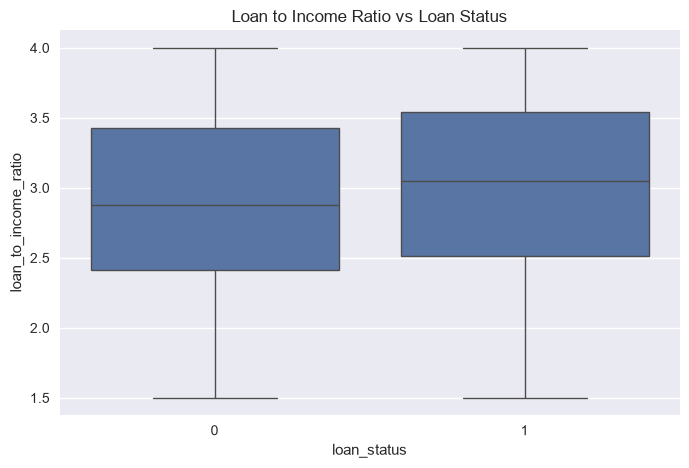

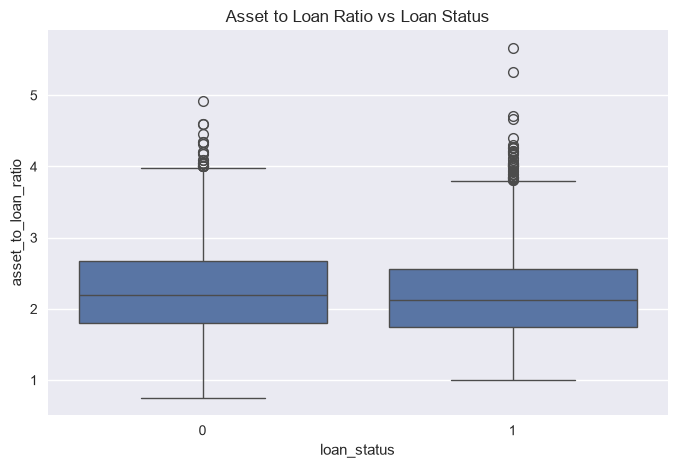

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x="loan_status", y="loan_to_income_ratio", data=df)
plt.title("Loan to Income Ratio vs Loan Status")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x="loan_status", y="asset_to_loan_ratio", data=df)
plt.title("Asset to Loan Ratio vs Loan Status")
plt.show()

In [68]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (4269, 14)
Target vector shape: (4269,)


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3415, 14)
X_test shape: (854, 14)
y_train shape: (3415,)
y_test shape: (854,)


In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numeric_cols = X.columns

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaling completed.")

Scaling completed.


Feature scaling was applied using StandardScaler to normalize the numerical feature values. This is especially useful for machine learning algorithms that are sensitive to feature magnitude, such as Logistic Regression.